### 4 – Exploratory Data Analysis (EDA)

#### Theory & Industrial Relevance
Before modelling, thorough EDA uncovers data imbalances, feature correlations, and inherent separability. PCA and t‑SNE reveal whether classes form distinct clusters. Industrial datasets often contain outliers or mislabelled instances; EDA catches these early. For NDT, understanding feature distributions helps set alarm thresholds (e.g., kurtosis > 3.5 may indicate a crack).

Dataset shape: (5000, 24)

Class distribution:
class_name
Normal       1000
Crack        1000
Porosity     1000
Corrosion    1000
Inclusion    1000
Name: count, dtype: int64

Statistical Summary (selected features):
           rms   kurtosis  spectral_centroid  wavelet_energy_2
mean  0.192372   4.366118       5.216700e+06          0.106842
std   0.031030   2.766459       1.790266e+05          0.016231
min   0.111039   0.684606       5.003352e+06          0.060543
max   0.238297  10.612012       5.864052e+06          0.145115


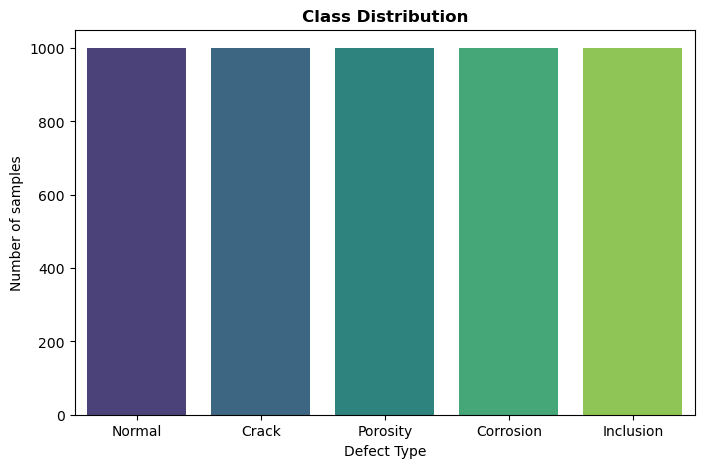

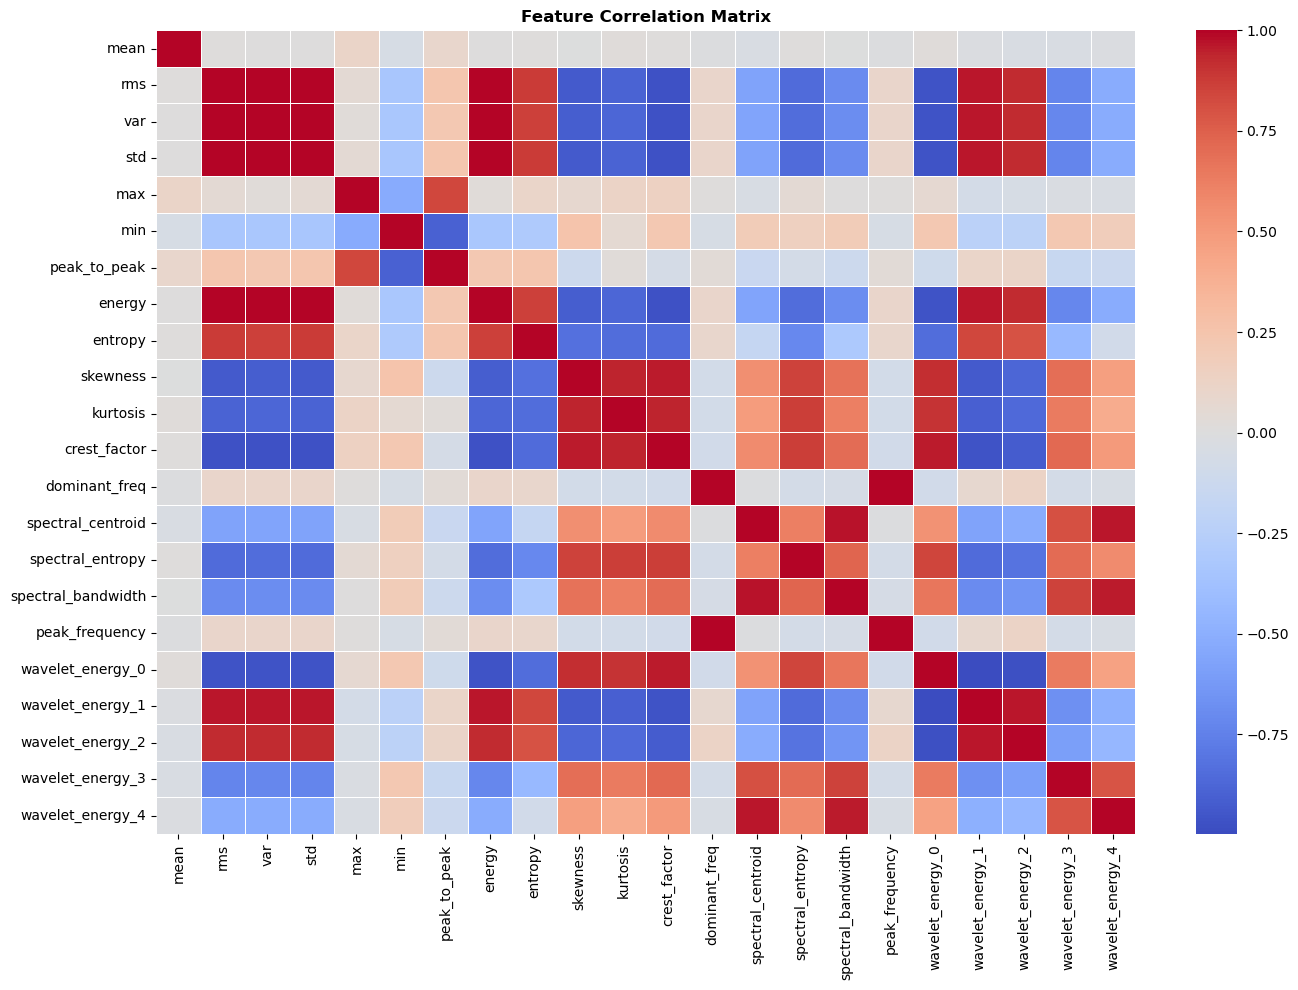

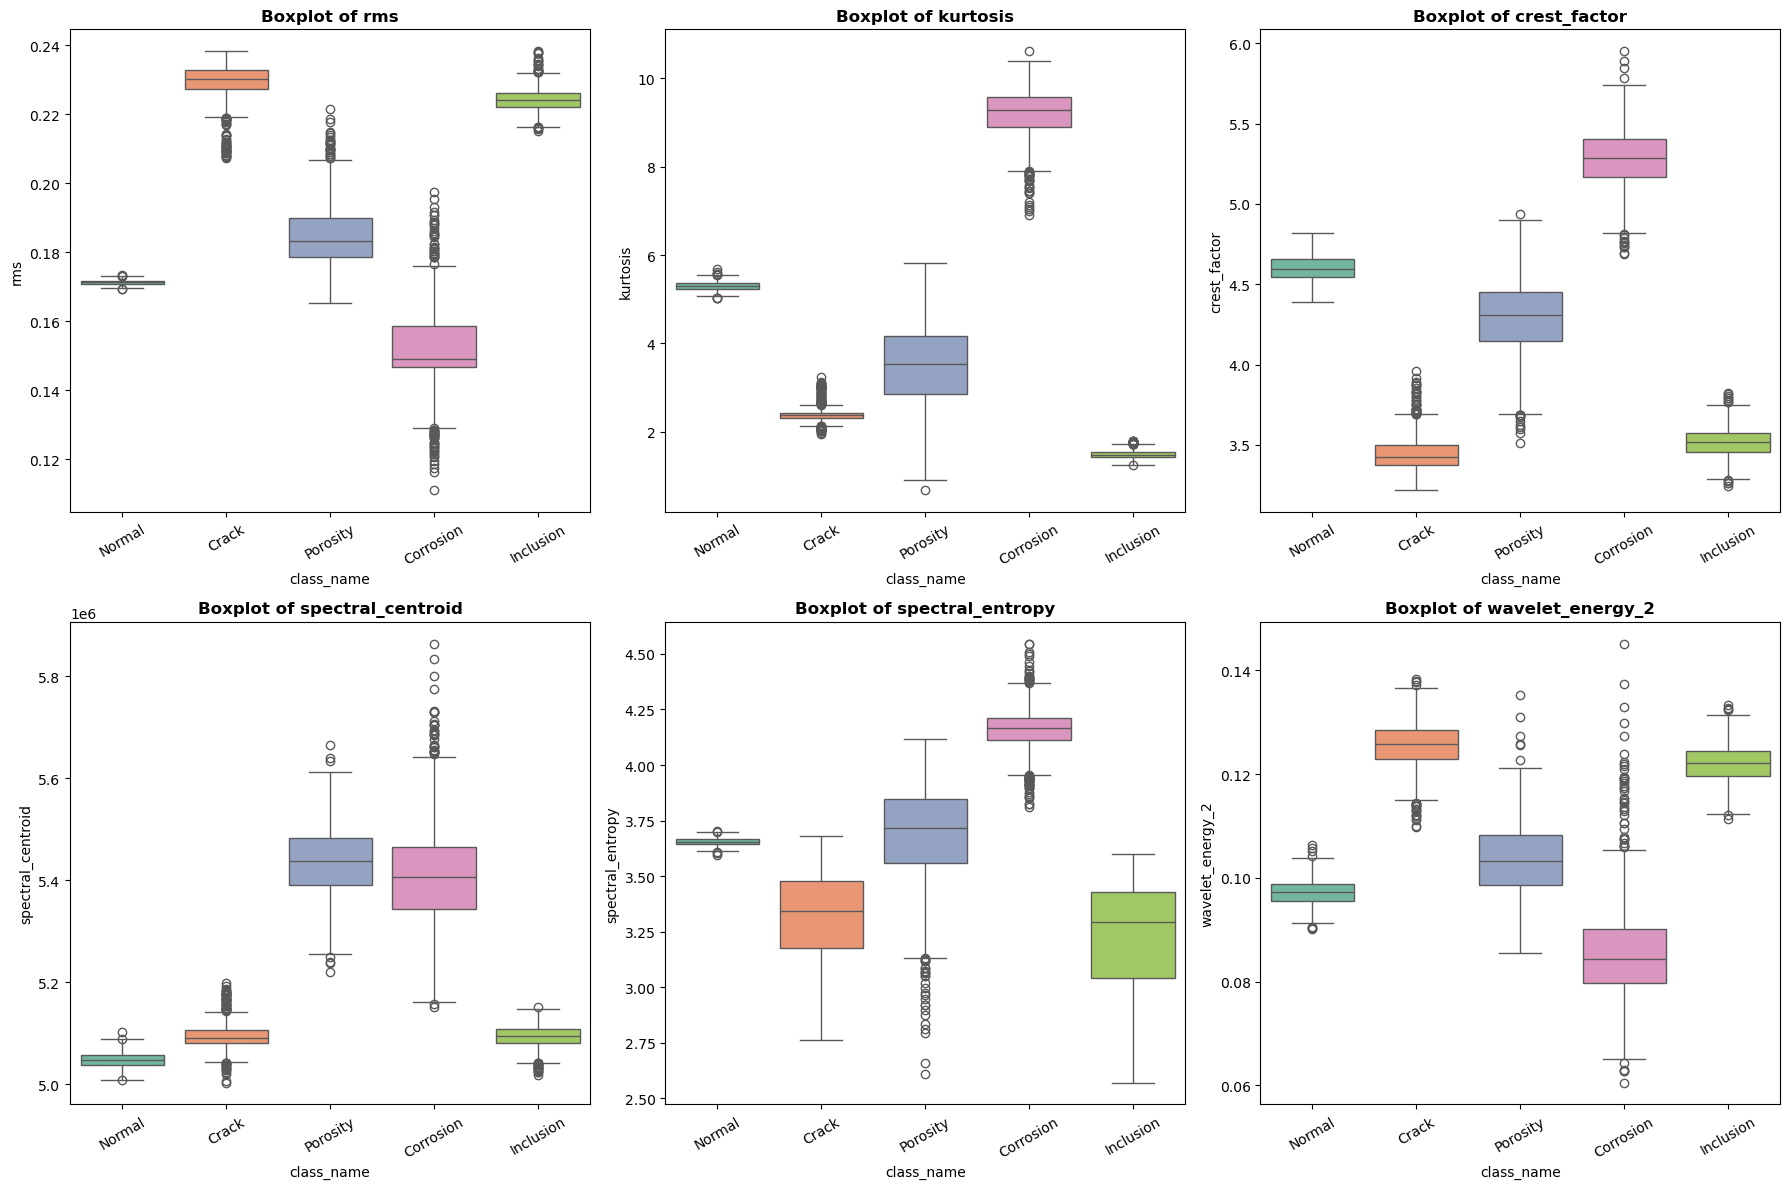

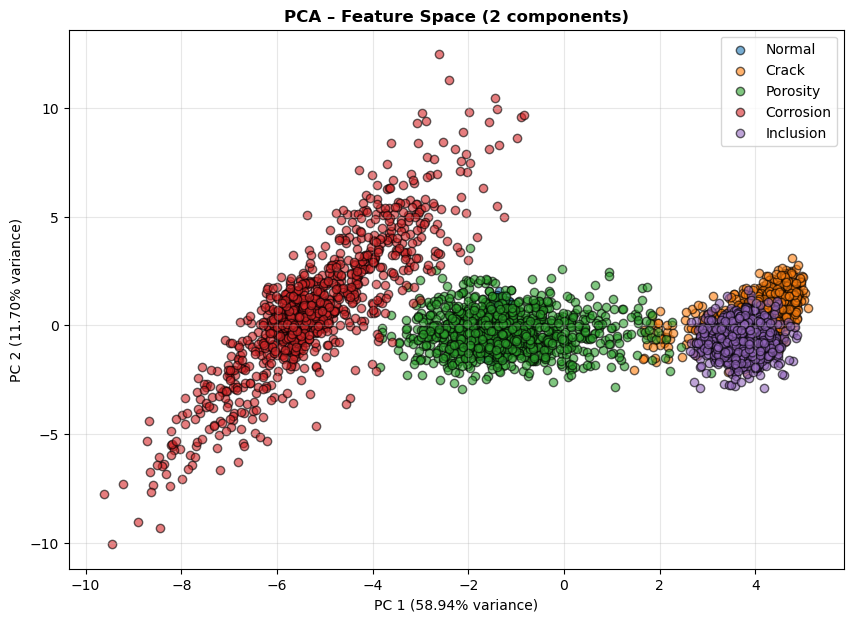

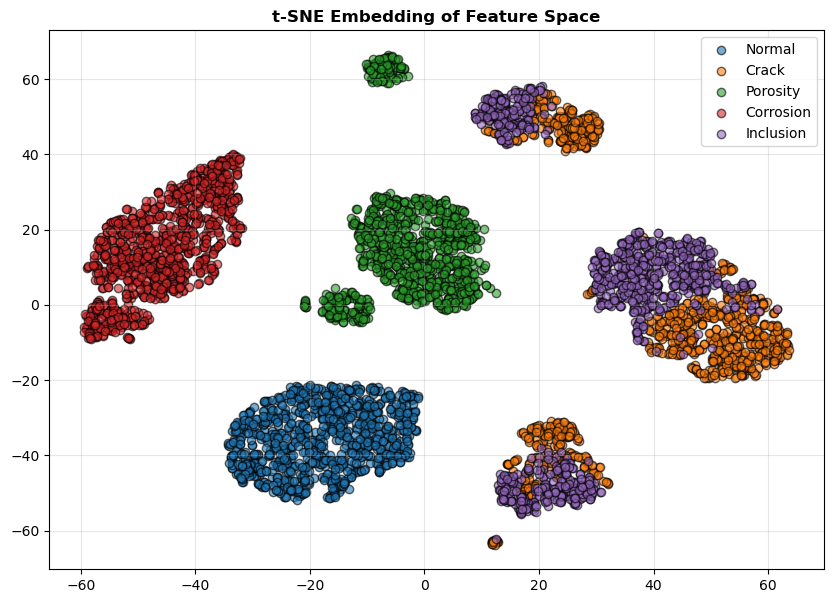

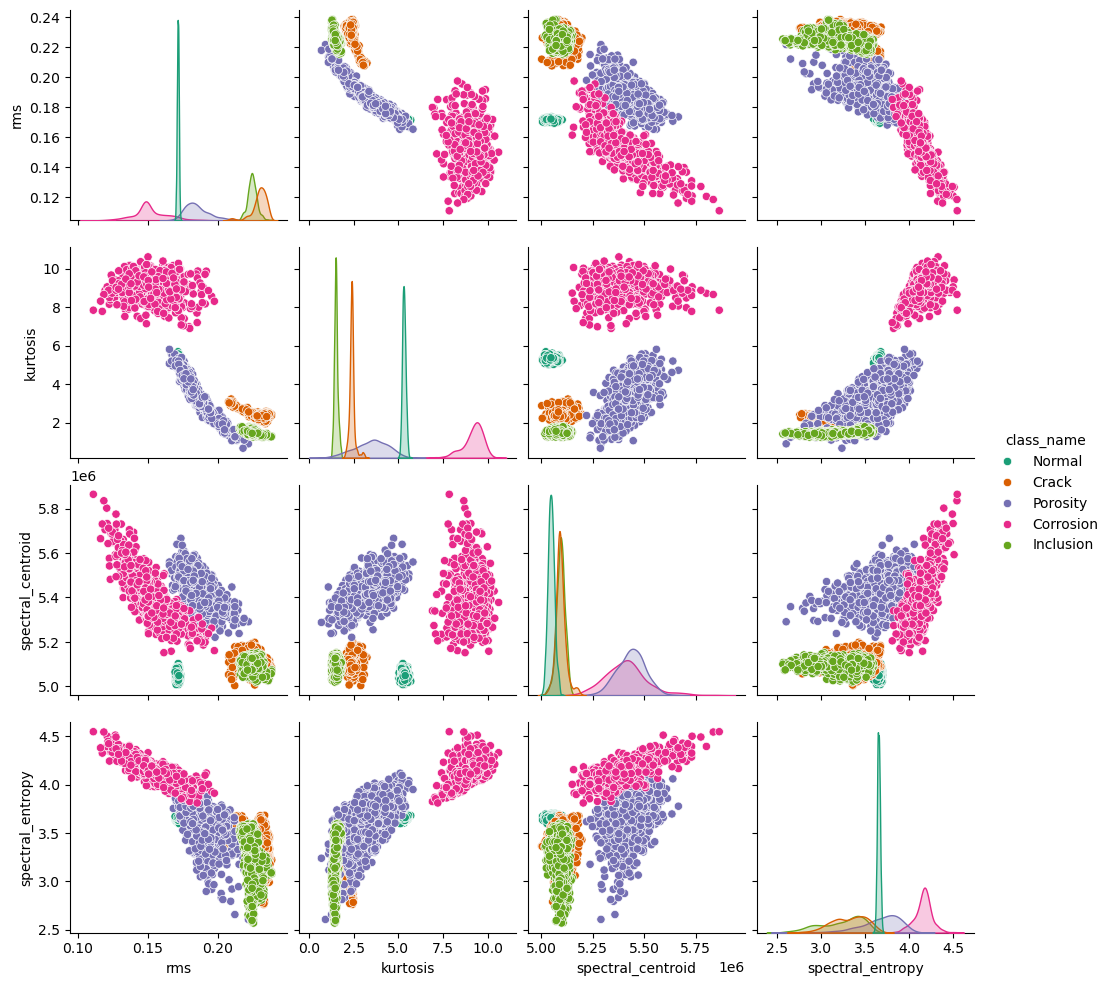

In [1]:
# ====================================================
# Notebook 04: EDA
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Load features
df = pd.read_csv("../data/processed/features.csv")
class_names = ["Normal", "Crack", "Porosity", "Corrosion", "Inclusion"]
df['class_name'] = df['label'].map(lambda x: class_names[x])

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['class_name'].value_counts())

# 1. Statistical summary
print("\nStatistical Summary (selected features):")
print(df.describe().loc[['mean', 'std', 'min', 'max'], ['rms', 'kurtosis', 'spectral_centroid', 'wavelet_energy_2']])

# 2. Class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class_name', palette='viridis')
plt.title("Class Distribution", fontweight='bold')
plt.xlabel("Defect Type")
plt.ylabel("Number of samples")
plt.savefig("../images/class_distribution.png", dpi=300)
plt.show()

# 3. Feature correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.drop(['label', 'class_name'], axis=1).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=300)
plt.show()

# 4. Boxplots of key features by class
key_features = ['rms', 'kurtosis', 'crest_factor', 'spectral_centroid', 'spectral_entropy', 'wavelet_energy_2']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='class_name', y=feat, palette='Set2', ax=axes[i])
    axes[i].set_title(f"Boxplot of {feat}", fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("../images/boxplots_features.png", dpi=300)
plt.show()

# 5. PCA and t‑SNE
X = df.drop(['label', 'class_name'], axis=1).values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for i, name in enumerate(class_names):
    mask = (y == i)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.6, edgecolor='k')
plt.title("PCA – Feature Space (2 components)", fontweight='bold')
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("../images/pca_scatter.png", dpi=300)
plt.show()

# t‑SNE (use a subsample to speed up, but here we can use full dataset – careful may be slow)
tsne = TSNE(n_components=2, random_state=42, perplexity=40)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for i, name in enumerate(class_names):
    mask = (y == i)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=name, alpha=0.6, edgecolor='k')
plt.title("t‑SNE Embedding of Feature Space", fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("../images/tsne_scatter.png", dpi=300)
plt.show()

# 6. Pairplot (subset of features)
subset = df[['rms', 'kurtosis', 'spectral_centroid', 'spectral_entropy', 'class_name']]
sns.pairplot(subset, hue='class_name', diag_kind='kde', palette='Dark2')
plt.savefig("../images/pairplot.png", dpi=300)
plt.show()

#### Interpretation of Result

* Class balance is perfect (1000 each), so no resampling needed.

* Correlation heatmap reveals groups: time‑domain amplitude features (rms, max, peak‑to‑peak) are highly correlated; spectral entropy and wavelet energies offer independent information.

* Boxplots show distinct medians for crack vs. porosity in kurtosis and crest factor.

* PCA shows partial overlap between normal and corrosion; cracks and inclusions separate well. t‑SNE further clusters defects, indicating a non‑linear classifier may excel.